# Manchester Urban Heat Visualization
# This notebook visualizes the projected change in Manchester urban maximum temperature and the projected increase in hot days from 2050 to 2080.

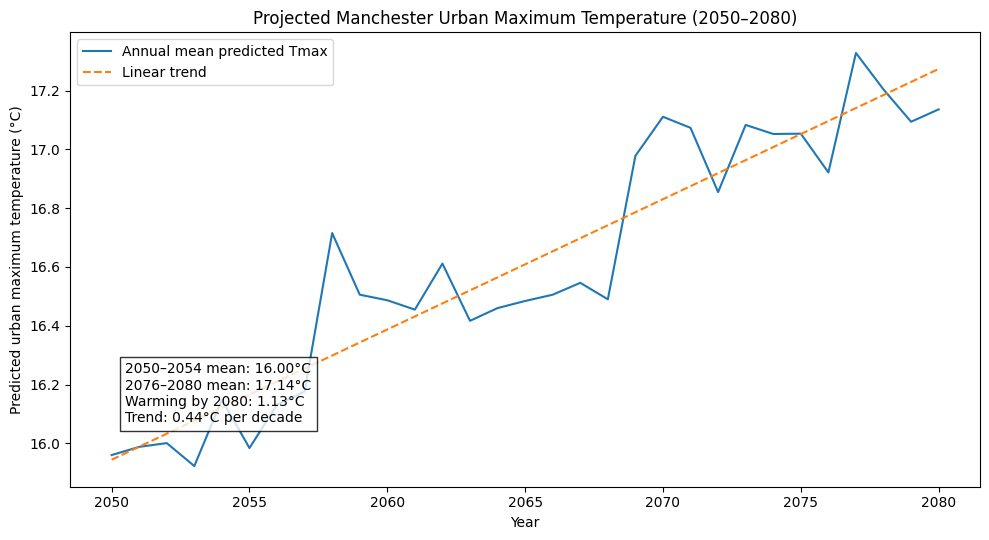

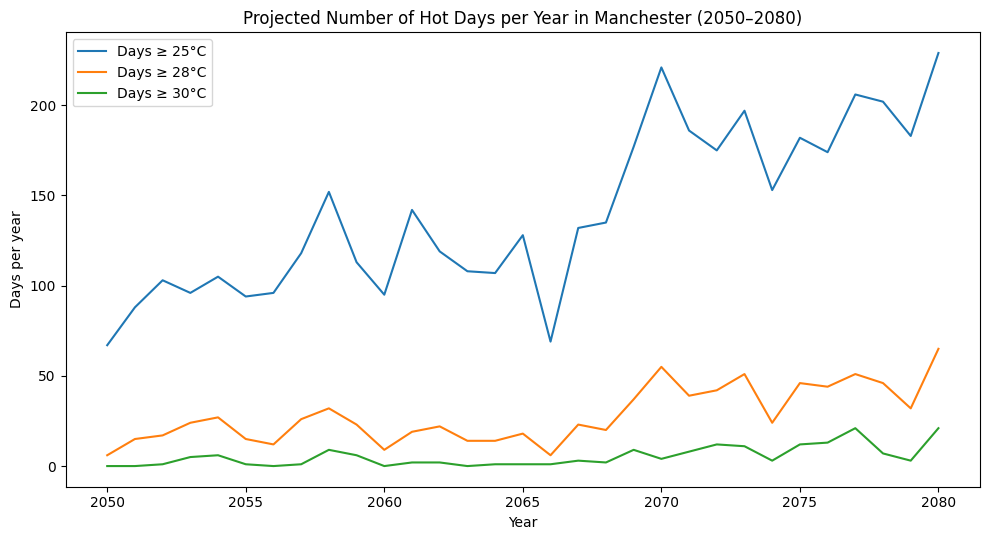

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("best_model_prediction_to_2080_12_31.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

temp_col = "Predicted"

# Annual mean projection
annual = df.groupby("Year")[temp_col].mean().reset_index()

coef = np.polyfit(annual["Year"], annual[temp_col], 1)
trend_fn = np.poly1d(coef)
annual["Trend"] = trend_fn(annual["Year"])

start_period = annual[(annual["Year"] >= 2050) & (annual["Year"] <= 2054)][temp_col].mean()
end_period = annual[(annual["Year"] >= 2076) & (annual["Year"] <= 2080)][temp_col].mean()
warming = end_period - start_period
warming_rate_decade = coef[0] * 10

plt.figure(figsize=(10, 5.5))
plt.plot(annual["Year"], annual[temp_col], label="Annual mean predicted Tmax")
plt.plot(annual["Year"], annual["Trend"], linestyle="--", label="Linear trend")
plt.title("Projected Manchester Urban Maximum Temperature (2050–2080)")
plt.xlabel("Year")
plt.ylabel("Predicted urban maximum temperature (°C)")
plt.legend()
plt.text(
    2050.5,
    annual[temp_col].min() + 0.15,
    f"2050–2054 mean: {start_period:.2f}°C\n"
    f"2076–2080 mean: {end_period:.2f}°C\n"
    f"Warming by 2080: {warming:.2f}°C\n"
    f"Trend: {warming_rate_decade:.2f}°C per decade",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)
plt.tight_layout()
plt.show()

# Hot-day frequency
thresholds = [25, 28, 30]
counts = pd.DataFrame({"Year": sorted(df["Year"].unique())})
for t in thresholds:
    counts[f"Days ≥ {t}°C"] = df.groupby("Year")[temp_col].apply(lambda s, thr=t: (s >= thr).sum()).values

plt.figure(figsize=(10, 5.5))
for col in counts.columns[1:]:
    plt.plot(counts["Year"], counts[col], label=col)
plt.title("Projected Number of Hot Days per Year in Manchester (2050–2080)")
plt.xlabel("Year")
plt.ylabel("Days per year")
plt.legend()
plt.tight_layout()
plt.show()
